# Parkflächen umverteilen

## Daten aufbereiten

### Parkflächen ermitteln
Quelle: Flächenmehrzweckkarte (FMZK) der Stadt Wien (https://www.data.gv.at/katalog/dataset/7cf0da04-1f77-4321-929e-78172c74aa0b)  
Stand: 15. Oktober 2024

Die FMZK enthält fehlerhafte Einträge:

```geopandas.read_file("fmzk.gpkg")```

```GEOSException: IllegalArgumentException: point array must contain 0 or >1 elements```

Umweg über QGIS:
* FMZK Geopackage importieren
* Layer filtern nach ```"F_KLASSE_TEXT" = "Ruhender Verkehr"```
* Layer CRS auf *EPSG: 31256* setzen
* Gefilterte Layer mit CRS *EPSG:3857* und ohne Metadaten exportieren als Geopackage

<Axes: >

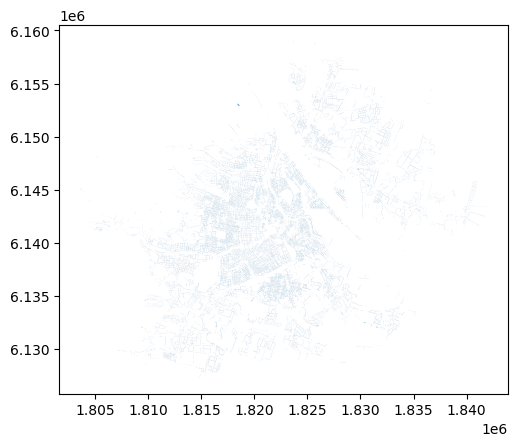

In [1]:
import geopandas as gpd

parkflaechen = gpd.read_file("parkflaechen_wien.gpkg")
parkflaechen.plot()

### Parkflächen in einzelne Parkplätze aufteilen
Parkflächen-Polygone können Löcher enthalten (z.B. Baumscheiben).  
Für die Aufteilung zunächst Polygone mit möglichst großen Rechtecken füllen.

Siehe largest interior rectangle: https://github.com/OpenStitching/lir

##### Polygone als numpy Arrays darstellen

In [2]:
from shapely.geometry import Polygon
import numpy as np
import largestinteriorrectangle as lir

def convert_3857_to_grid(poly, resolution):
    """
    Converts a polygon in EPSG:3857 (meters) into an integer grid.
    
    Parameters:
      poly (Polygon): A shapely Polygon with coordinates in EPSG:3857.
      resolution (float): Size of one grid cell in meters (e.g., 1.0 = 1 meter per cell).
      
    Returns:
      grid_poly (Polygon): The polygon in grid (integer) coordinates.
      offset (tuple): (minx, miny) in meter coordinates used to translate the polygon.
      resolution (float): The resolution (meters per grid cell).
    """
    # Get the polygon's exterior coordinates
    coords = list(poly.exterior.coords)
    xs, ys = zip(*coords)
    
    # Find the bounding box of the polygon in EPSG:3857 (meters)
    minx, miny, maxx, maxy = min(xs), min(ys), max(xs), max(ys)
    
    # Translate the polygon so that the lower-left corner is at (0,0)
    translated_coords = [(x - minx, y - miny) for x, y in coords]
    
    # Convert the translated coordinates to grid coordinates
    grid_coords = [(int(round(x / resolution)), int(round(y / resolution))) 
                   for x, y in translated_coords]
    
    grid_poly = Polygon(grid_coords)
    return grid_poly, (minx, miny), resolution


def convert_grid_rect_to_3857(rect, offset, resolution):
    """
    Converts a rectangle from grid coordinates back to EPSG:3857.
    
    Parameters:
      rect (array-like): [x, y, width, height] in grid cells, where (x, y) is the lower-left corner.
      offset (tuple): (minx, miny) that was subtracted during the grid conversion.
      resolution (float): Meters per grid cell.
      
    Returns:
      tuple: (x_3857, y_3857, width_3857, height_3857) in EPSG:3857 meters.
    """
    x_grid, y_grid, width_grid, height_grid = rect
    minx, miny = offset
    
    # Convert the lower-left grid cell back to meter coordinates
    x_3857 = x_grid * resolution + minx
    y_3857 = y_grid * resolution + miny
    
    # Convert width and height from grid cells to meters
    width_3857 = width_grid * resolution
    height_3857 = height_grid * resolution
    
    return (x_3857, y_3857, width_3857, height_3857)


KeyboardInterrupt



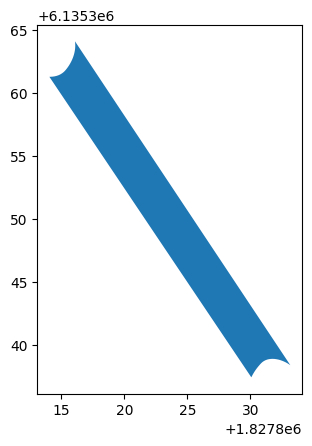

In [5]:
for index, row in parkflaechen.iterrows():
  grid_poly, offset, res = convert_3857_to_grid(row.geometry, resolution=1)
  rectangle = lir.lir(np.array([grid_poly.exterior.coords], np.int32))
  row['lir'] = convert_grid_rect_to_3857(rectangle, offset, res)
  parkflaechen.loc[[index],'geometry'].plot()
  parkflaechen.loc[[index],'lir'].plot()